In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df=pd.read_csv('..//Data/Cleaned_Data7.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Relative_Compactness  384 non-null    float64
 1   Wall_Area             384 non-null    float64
 2   Roof_Area             384 non-null    float64
 3   Heating_Load          384 non-null    float64
 4   Cooling_Load          384 non-null    float64
 5   Ori_3                 384 non-null    bool   
 6   Ori_4                 384 non-null    bool   
 7   Ori_5                 384 non-null    bool   
 8   GA_0.1                384 non-null    bool   
 9   GA_0.25               384 non-null    bool   
 10  GA_0.4                384 non-null    bool   
 11  GD_1                  384 non-null    bool   
 12  GD_2                  384 non-null    bool   
 13  GD_3                  384 non-null    bool   
 14  GD_4                  384 non-null    bool   
 15  GD_5                  384 non-null

In [5]:
# Setting feature (X) and targets(Y-working for both Heating and Cooling)
X = df.drop(columns=["Heating_Load","Cooling_Load"])
Y= df[["Heating_Load","Cooling_Load"]]
XN = ['Relative_Compactness','Wall_Area',"Roof_Area"]
XD = ['Ori_3','Ori_4','Ori_5','GA_0.1','GA_0.25','GA_0.4','GD_1',"GD_2",'GD_3','GD_4','GD_5']
#TrainTestSplit
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state=42)
#Enable Scaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[XN]=scaler.fit_transform(X_train[XN])
X_test_scaled[XN]=scaler.transform(X_test[XN])
#running LinearRegression 
#lrh for Heating
lrh = LinearRegression() 
lrh.fit(X_train_scaled, Y_train["Heating_Load"])
y_predh=lrh.predict(X_test_scaled)
#lrc for Cooling
lrc = LinearRegression() 
lrc.fit(X_train_scaled, Y_train["Cooling_Load"])
y_predc=lrc.predict(X_test_scaled)
#Calculate the evaluations 
rmse_h =round(np.sqrt(mean_squared_error(Y_test['Heating_Load'], y_predh)), 2)
r2_h = round(r2_score(Y_test['Heating_Load'], y_predh), 2)
mse_h = round(mean_squared_error(Y_test['Heating_Load'], y_predh),2)

rmse_c =round(np.sqrt(mean_squared_error(Y_test['Cooling_Load'], y_predc)), 2)
r2_c = round(r2_score(Y_test['Cooling_Load'], y_predc), 2)
mse_c = round(mean_squared_error(Y_test['Cooling_Load'], y_predc),2)
#to print the metrics in a reader friendly way
print("Heating Load")
print(f"RMSE: {rmse_h}, R2: {r2_h}, MSE: {mse_h}")
print("Cooling Load")
print(f"RMSE: {rmse_c}, R2: {r2_c}, MSE: {mse_c}")

Heating Load
RMSE: 2.96, R2: 0.75, MSE: 8.79
Cooling Load
RMSE: 3.82, R2: 0.53, MSE: 14.62


The Heating Model covers 75% of variance, while the Cooling only covers 53% 
The Heating prediction can be off by 2.96, while cooling is 3.82. (Plus or Minus)
The low R2 with Cooling is indicating the model may not be good. 
This 7M Height model shows the similar reading with 3.5M model

In [6]:
#Checking OverFitting
# Heating
y_train_predh = lrh.predict(X_train_scaled)
train_r2_h = r2_score(Y_train["Heating_Load"], y_train_predh)
test_r2_h = r2_score(Y_test["Heating_Load"], y_predh)

# Cooling
y_train_predc = lrc.predict(X_train_scaled)
train_r2_c = r2_score(Y_train["Cooling_Load"], y_train_predc)
test_r2_c = r2_score(Y_test["Cooling_Load"], y_predc)

print(f"Heating Load - Train R2: {train_r2_h:.3f}, Test R2: {test_r2_h:.3f}")
print(f"Cooling Load - Train R2: {train_r2_c:.3f}, Test R2: {test_r2_c:.3f}")

Heating Load - Train R2: 0.780, Test R2: 0.752
Cooling Load - Train R2: 0.593, Test R2: 0.529


The Heating Load have relative smaller difference-no overfitting
the Cooling Load does have signs of overfitting

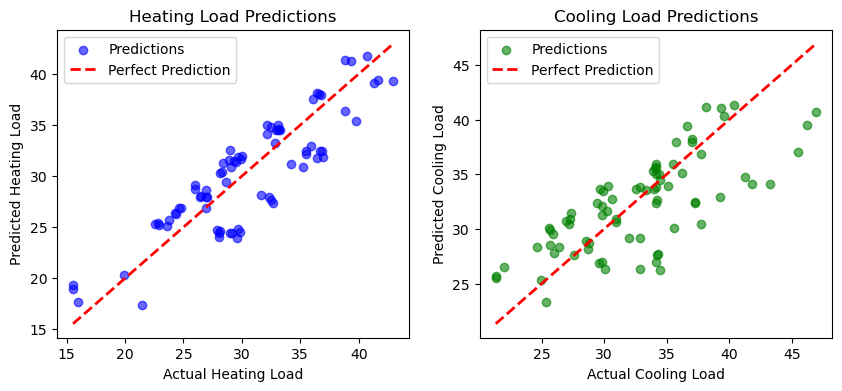

In [7]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
# Heating Model
ax = axes[0]
ax.scatter(Y_test['Heating_Load'], y_predh, color='blue', alpha=0.6, label='Predictions')
min_val = min(Y_test['Heating_Load'].min(), y_predh.min())
max_val = max(Y_test['Heating_Load'].max(), y_predh.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Heating Load')
ax.set_ylabel('Predicted Heating Load')
ax.set_title('Heating Load Predictions')
ax.legend()

# Cooling Model
ax = axes[1]
ax.scatter(Y_test['Cooling_Load'], y_predc, color='green', alpha=0.6, label='Predictions')
min_val = min(Y_test['Cooling_Load'].min(), y_predc.min())
max_val = max(Y_test['Cooling_Load'].max(), y_predc.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Cooling Load')
ax.set_ylabel('Predicted Cooling Load')
ax.set_title('Cooling Load Predictions')
ax.legend()

plt.show()

The graph shows clear picture of the heating model have a postive trend between the actual and pridiction, as the blue dots are relatively closer to the prediction line and also shows similar pattern going up or down. 

The cooling model graph has the green dots that further off from the perfect prediction line, in comparison to the heating model. And also have the similar pattern as from 3.5M model. 

In [9]:
# Initialize Lasso (alpha controls regularization strength; higher alpha = more shrinkage)
lasso_h = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso_c = Lasso(alpha=0.1, random_state=42, max_iter=10000)

# Fit to training data
lasso_h.fit(X_train_scaled, Y_train["Heating_Load"])
lasso_c.fit(X_train_scaled, Y_train["Cooling_Load"])
# Predict on test set
y_predh_lasso = lasso_h.predict(X_test_scaled)
y_predc_lasso = lasso_c.predict(X_test_scaled)

# Evaluate
rmse_h_lasso = round(np.sqrt(mean_squared_error(Y_test['Heating_Load'], y_predh_lasso)), 2)
r2_h_lasso = round(r2_score(Y_test['Heating_Load'], y_predh_lasso), 2)
rmse_c_lasso = round(np.sqrt(mean_squared_error(Y_test['Cooling_Load'], y_predc_lasso)), 2)
r2_c_lasso = round(r2_score(Y_test['Cooling_Load'], y_predc_lasso), 2)
print("Heating Load - Lasso")
print(f"RMSE: {rmse_h_lasso}, R2: {r2_h_lasso}")
print("Cooling Load - Lasso")
print(f"RMSE: {rmse_c_lasso}, R2: {r2_c_lasso}")

Heating Load - Lasso
RMSE: 3.87, R2: 0.58
Cooling Load - Lasso
RMSE: 4.31, R2: 0.4


Lasso Regression have decreased both models R2, means the modesl are representing less variance of the data, not so good. 

In [10]:
#Checking OverFitting
# Heating Load
r2_h_train_lasso = r2_score(Y_train["Heating_Load"], lasso_h.predict(X_train_scaled))

# Cooling Load
r2_c_train_lasso = r2_score(Y_train["Cooling_Load"], lasso_c.predict(X_train_scaled))

print(f"Heating Load - Train R2: {r2_h_train_lasso:.3f}, Test R2: {r2_h_lasso:.3f}")
print(f"Cooling Load - Train R2: {r2_c_train_lasso:.3f}, Test R2: {r2_c_lasso:.3f}")

Heating Load - Train R2: 0.607, Test R2: 0.580
Cooling Load - Train R2: 0.446, Test R2: 0.400


Lasso model have smaller R2, same trend as 3.5M

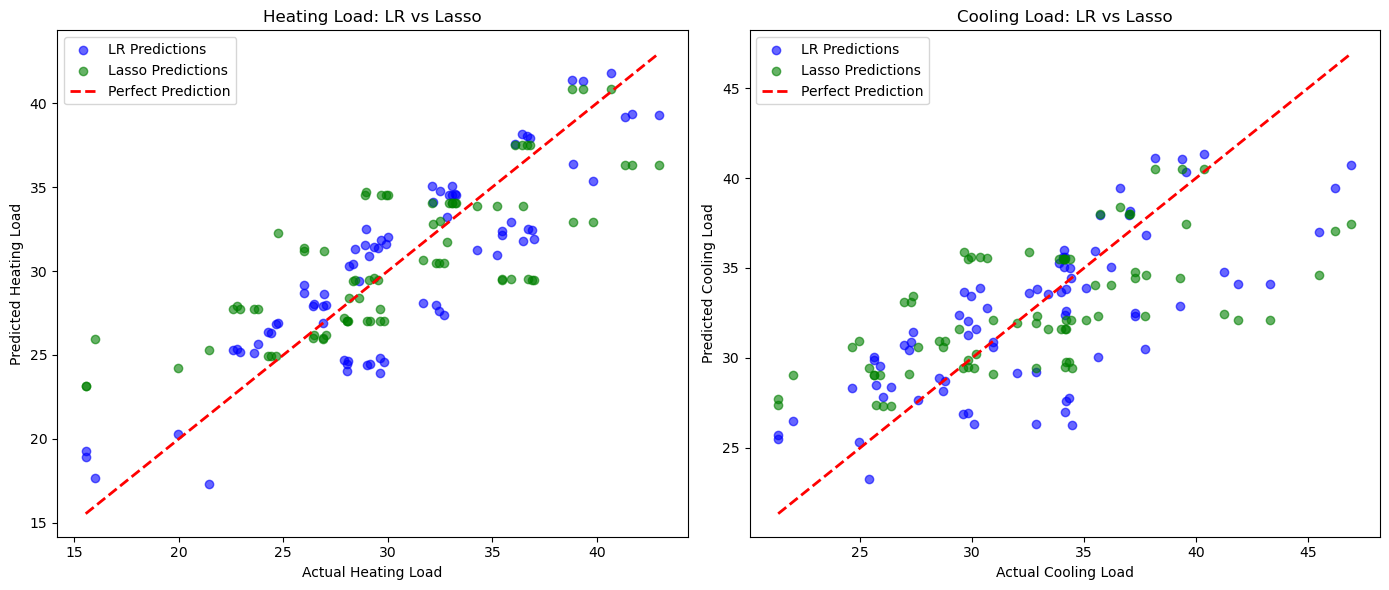

In [11]:
#Plot both Lasso and LR together 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heating Load
ax = axes[0]
# Linear Regression predictions
ax.scatter(Y_test['Heating_Load'], y_predh, color='blue', alpha=0.6, label='LR Predictions')
# Lasso predictions
ax.scatter(Y_test['Heating_Load'], y_predh_lasso, color='green', alpha=0.6, label='Lasso Predictions')

# Perfect prediction line
min_val = min(Y_test['Heating_Load'].min(), y_predh.min(), y_predh_lasso.min())
max_val = max(Y_test['Heating_Load'].max(), y_predh.max(), y_predh_lasso.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Heating Load')
ax.set_ylabel('Predicted Heating Load')
ax.set_title('Heating Load: LR vs Lasso')
ax.legend()

# Cooling Load
ax = axes[1]
# Linear Regression predictions
ax.scatter(Y_test['Cooling_Load'], y_predc, color='blue', alpha=0.6, label='LR Predictions')
# Lasso predictions
ax.scatter(Y_test['Cooling_Load'], y_predc_lasso, color='green', alpha=0.6, label='Lasso Predictions')

# Perfect prediction line
min_val = min(Y_test['Cooling_Load'].min(), y_predc.min(), y_predc_lasso.min())
max_val = max(Y_test['Cooling_Load'].max(), y_predc.max(), y_predc_lasso.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Cooling Load')
ax.set_ylabel('Predicted Cooling Load')
ax.set_title('Cooling Load: LR vs Lasso')
ax.legend()

plt.tight_layout()
plt.show()


It seems the green dots are showing a curve/less 45 degree angle pattern, while the blue dots are more aling with the perfect line. It sugesst the Lasso is underfitting and LR is better fitted model. 
LR


Text(0.5, 1.0, 'Residuals vs Fitted for Cooling_Load Lasso')

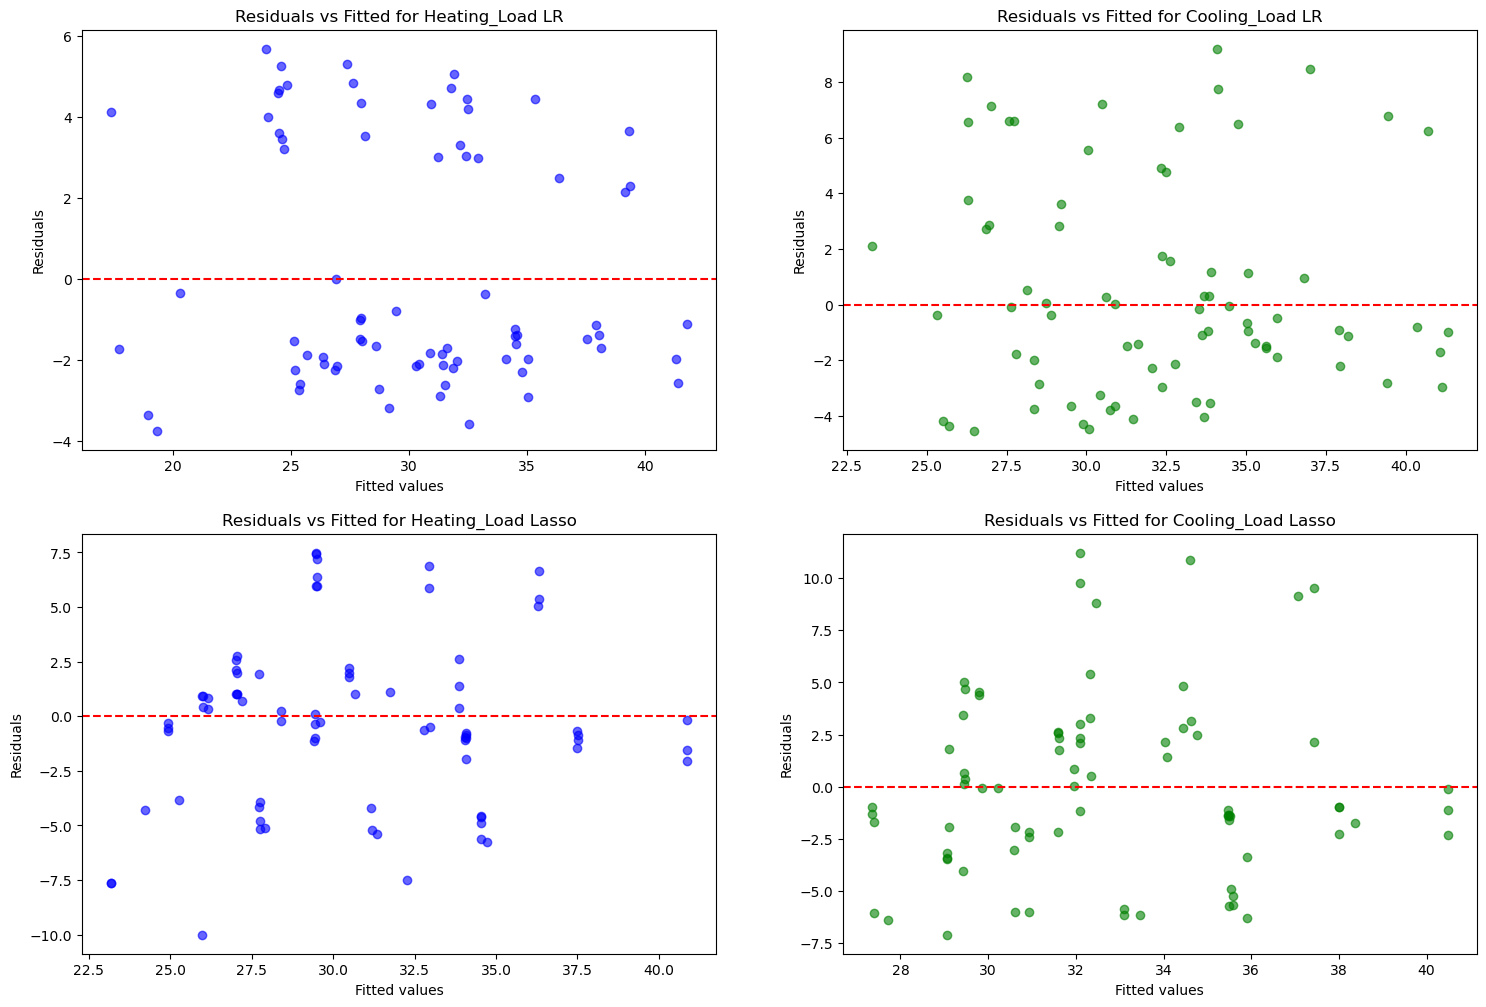

In [12]:
#residual Values
res_h = Y_test["Heating_Load"] - y_predh
res_c = Y_test["Cooling_Load"] - y_predc
resl_h = Y_test["Heating_Load"] - y_predh_lasso
resl_c = Y_test["Cooling_Load"] - y_predc_lasso
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
width = 0.6

# Heating Load LR
axes[0,0].scatter(y_predh, res_h, color='blue', alpha=0.6)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel("Fitted values")
axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title("Residuals vs Fitted for Heating_Load LR")

# Cooling Load LR
axes[0,1].scatter(y_predc, res_c, color='green', alpha=0.6)
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_xlabel("Fitted values")
axes[0,1].set_ylabel("Residuals")
axes[0,1].set_title("Residuals vs Fitted for Cooling_Load LR")

# Heating Load Lasso
axes[1,0].scatter(y_predh_lasso, resl_h, color='blue', alpha=0.6)
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_xlabel("Fitted values")
axes[1,0].set_ylabel("Residuals")
axes[1,0].set_title("Residuals vs Fitted for Heating_Load Lasso")

# Cooling Load Lasso
axes[1,1].scatter(y_predc_lasso, resl_c, color='green', alpha=0.6)
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_xlabel("Fitted values")
axes[1,1].set_ylabel("Residuals")
axes[1,1].set_title("Residuals vs Fitted for Cooling_Load Lasso")

The graphs shows same trend as the 3.5M, however the residual value range seems increased in this dataset. 

In [ ]:
#Creating dataframe for coefficients 
lasso_coefs_h = pd.Series(lasso_h.coef_, index=X_train.columns)
lasso_coefs_c = pd.Series(lasso_c.coef_, index=X_train.columns)
lr_coefs_h= pd.Series(lrh.coef_, index=X_train.columns)
lr_coefs_c= pd.Series(lrc.coef_, index=X_train.columns)

coef_df = pd.DataFrame({
    'LR_Heating': lr_coefs_h.round(2),
    'LR_Cooling': lr_coefs_c.round(2),
    'Lasso_Heating': lasso_coefs_h.round(2),
    'Lasso_Cooling': lasso_coefs_c.round(2)
})

print(coef_df)

                      LR_Heating  LR_Cooling  Lasso_Heating  Lasso_Cooling
Relative_Compactness       71.06       63.71          -0.00          -0.00
Wall_Area                  61.13       54.70           2.99           2.58
Roof_Area                  47.34       42.76           0.43           0.70
Ori_3                      -0.05       -0.71           0.00          -0.04
Ori_4                      -0.54       -0.70          -0.02          -0.03
Ori_5                      -0.39        0.19           0.00           0.33
GA_0.1                      3.37        0.99           1.77          -0.00
GA_0.25                     6.81        3.90           5.21           2.52
GA_0.4                     10.12        6.34           8.57           4.97
GD_1                        4.25        2.58           0.00           0.00
GD_2                        4.31        2.42           0.17           0.00
GD_3                        3.71        2.03           0.00           0.00
GD_4                     

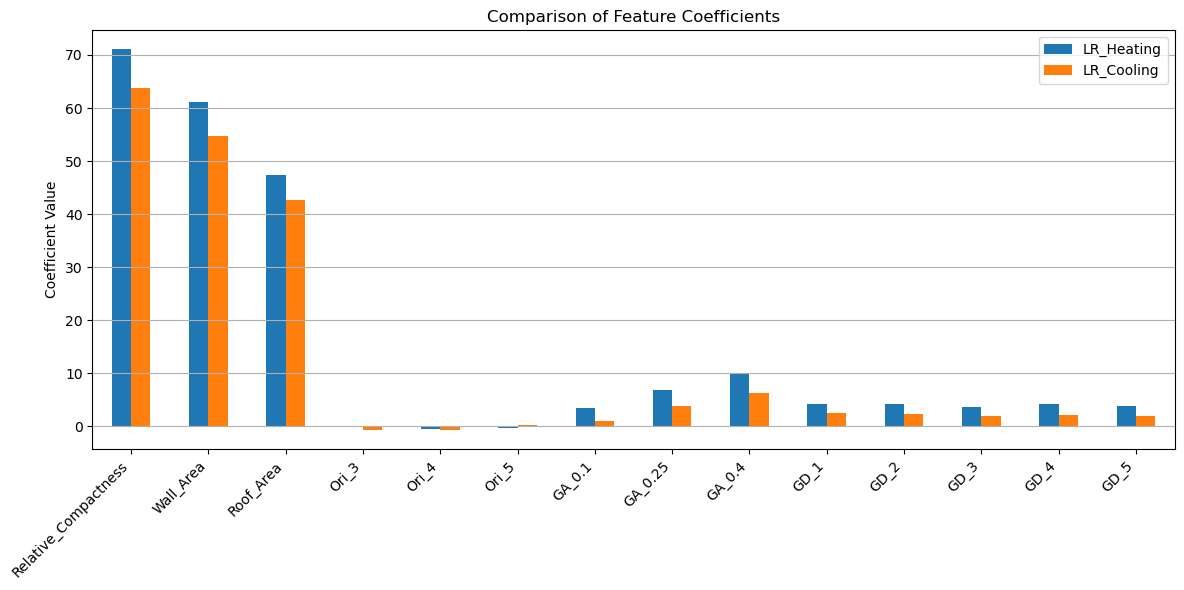

In [14]:
coef_df[['LR_Heating','LR_Cooling']].plot(kind='bar', figsize=(12,6))
plt.ylabel("Coefficient Value")
plt.title("Comparison of Feature Coefficients")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Throughout the previous analysis, the 7m models showed several similarities to 3.5m.
However, the calculated coefficients seem unrealistically high.
It seems unrealistic that a one-unit increase in Wall_Area would result in such a large increase in energy need for both heating and cooling. 
These values make interpretation difficult and less meaningful. Not comfortable with these, need to run Lasso. 




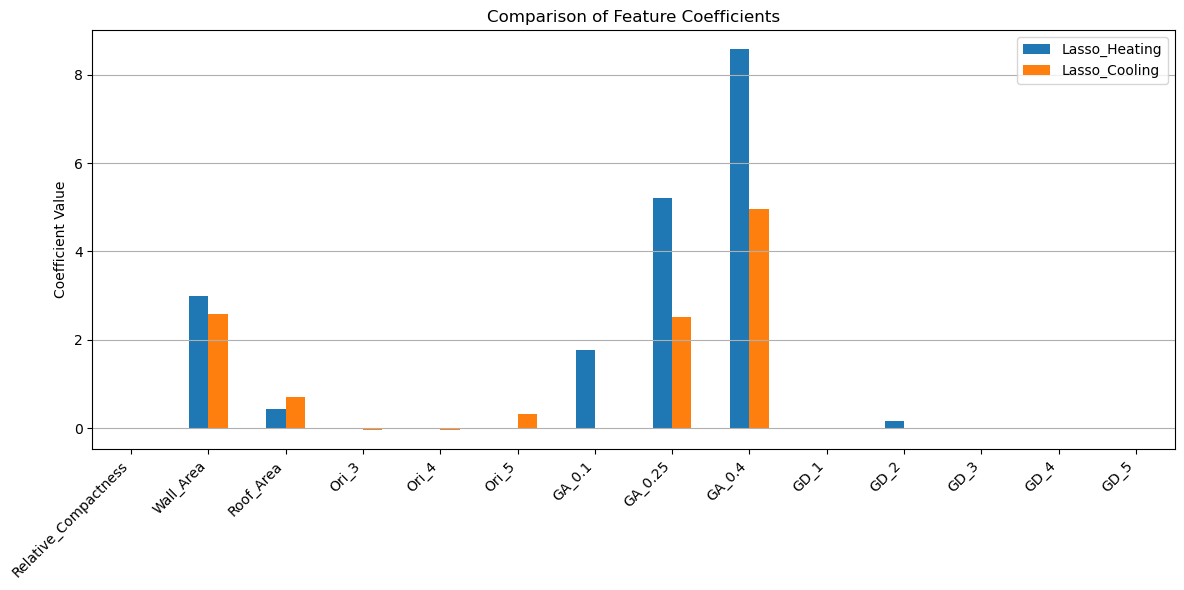

In [18]:
coef_df[['Lasso_Heating','Lasso_Cooling']].plot(kind='bar', figsize=(12,6))
plt.ylabel("Coefficient Value")
plt.title("Comparison of Feature Coefficients")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Lasso regression penalizes less important or correlated features, shrinking their coefficients toward zero. Therefor, the spike of coefficients are gone, and they are more reliable. (However, the model itself is not as precise, since the R2s are relatively low.)